# **Problem Statement**

In [3]:
# Task 3: Heart Disease Prediction

## Objective
#The objective of this project is to predict whether a person is at risk of heart disease using medical attributes.

## Dataset
#Heart Disease UCI Dataset

## Model Used
#Logistic Regression

# **Import Libraries**

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# **Upload Dataset**

# **Load Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci (1).csv


# **Dataset Inspection**

In [7]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [8]:
print("Shape:", df.shape)

Shape: (920, 16)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [10]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


# **Missing Values Check**

In [11]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


# **Exploratory Data Analysis (EDA)**

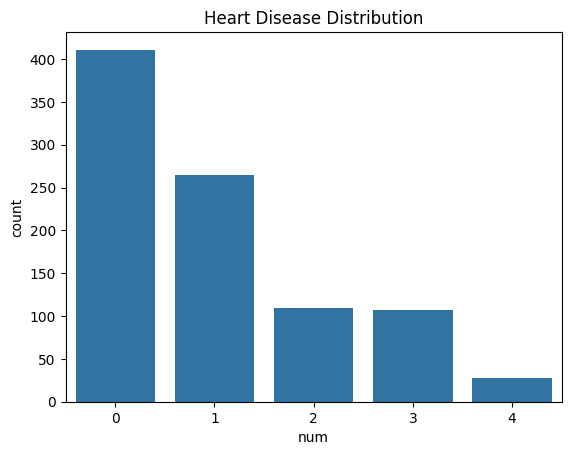

In [14]:
sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
num = 0   → No Heart Disease

num > 0   → Heart Disease

# **Target Distribution**

In [15]:
df['target'] = (df['num'] > 0).astype(int)

df[['num','target']].head()

,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


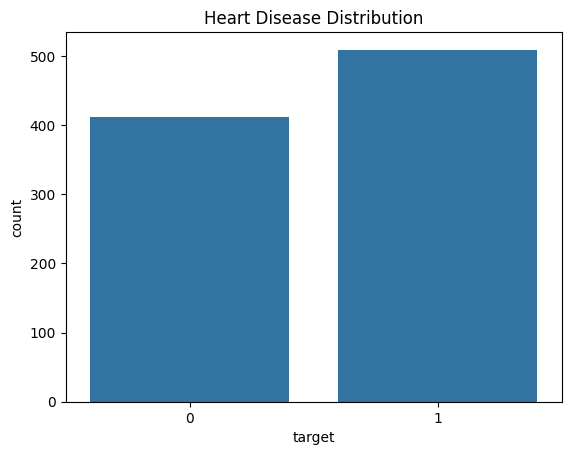

In [16]:
sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")

plt.show()

# **Prepare Features and Target**

In [17]:
X = df.drop(['id','num','target'], axis=1)

y = df['target']

# **Missing Values Check**

In [18]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [19]:
for col in df.columns:

    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

    else:
        df[col] = df[col].fillna(df[col].median())

/tmp/ipykernel_1977/3704484768.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


# **Convert Text Columns to Numbers**

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# **Check Data Types**

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    int64  
 3   dataset   920 non-null    int64  
 4   cp        920 non-null    int64  
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    int64  
 9   thalch    920 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    int64  
 13  ca        920 non-null    float64
 14  thal      920 non-null    int64  
 15  num       920 non-null    int64  
 16  target    920 non-null    int64  
dtypes: bool(2), float64(5), int64(10)
memory usage: 109.7 KB


In [22]:
X = df.drop(['id','num','target'], axis=1)

y = df['target']

# **Train model**

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7989130434782609


# **Confusion Matrix**

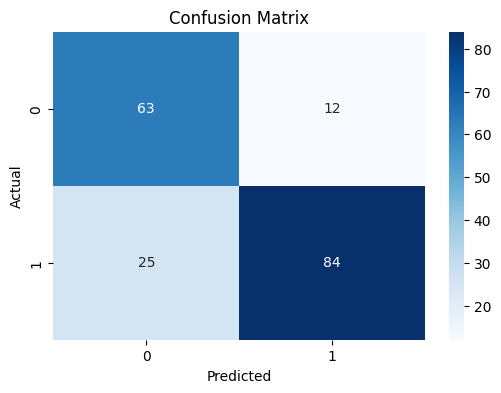

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Classification Report**

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.84      0.77        75
           1       0.88      0.77      0.82       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.80       184



# **ROC Curve**

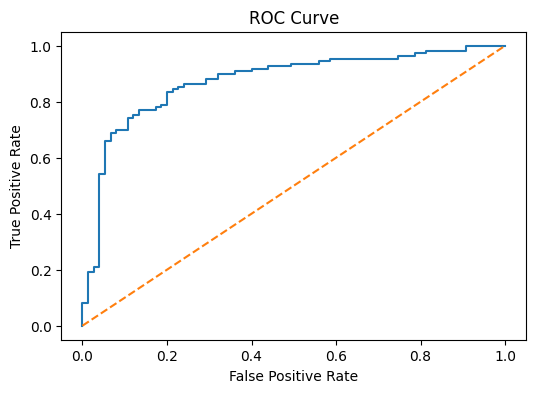

In [29]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

# **ROC-AUC Score**

In [30]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8732721712538226


# **Feature Importance Graph**

In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

     Feature  Coefficient
1        sex     1.386099
12        ca     1.028342
9      exang     1.018600
10   oldpeak     0.625837
13      thal     0.363623
2    dataset     0.362184
6        fbs     0.301032
7    restecg     0.030472
0        age     0.007069
4   trestbps     0.003711
5       chol    -0.004009
8     thalch    -0.012162
11     slope    -0.227600
3         cp    -0.630571


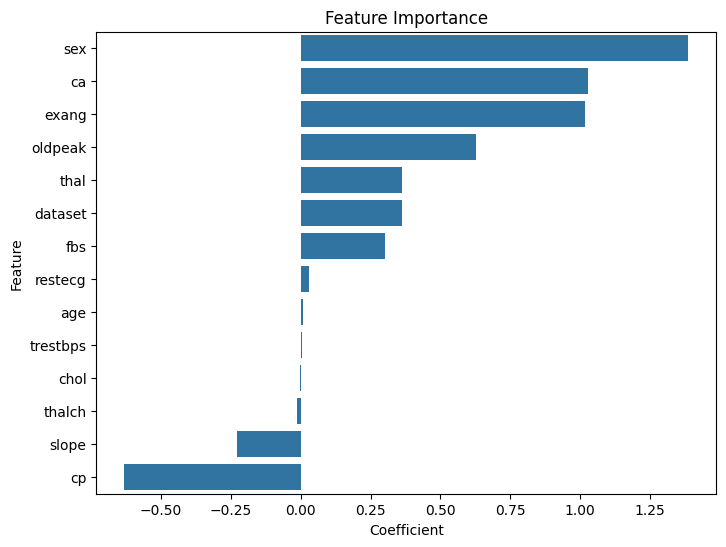

In [32]:
plt.figure(figsize=(8,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Final Conclusion
# Conclusion

A Logistic Regression model was developed to predict heart disease risk using patient medical data.

Results:
- Accuracy Score: 79.89%
- ROC-AUC Score: 87%

Key Findings:
- The model successfully classified patients with good accuracy.
- Several medical features showed strong influence on prediction.
- Logistic Regression proved effective for this binary classification task.

This model can assist in identifying individuals who may be at risk of heart disease.